# Notebook 03 — Confusion Line Validation

Memvalidasi bahwa pasangan warna di plate Ishihara berada di sepanjang
**confusion line** CIE 1931 — garis di chromaticity diagram yang
menghubungkan warna-warna yang tidak dapat dibedakan penderita CVD

## Tahapan

| Cell | Tahap | Deskripsi | Output |
|------|-------|-----------|--------|
| 1 | Setup | Imports & konstanta global | — |
| 2 | Fungsi | Konversi warna & jarak (self-contained) | — |
| 3 | 3A | Load metadata & cluster dari NB00 | — |
| 4 | 3B | Konversi HSV → CIE xy chromaticity | records |
| 5 | 3C | Plot chromaticity overview | `chromaticity_overview.png` |
| 6 | 3C | Plot detail per plate | `chromaticity_per_plate.png` |
| 7 | 3D | Threshold sweep empiris | `threshold_sweep.png` |
| 8 | 3D | Validasi final dual threshold | `validation_distances.png` |
| 9 | 3E | Proximity analysis plate insufficient | — |
| 10 | 3F | Ekspor JSON + ringkasan | `confusion_line_validation.json` |

Threshold ditetapkan **terpisah per CVD type** karena perbedaan geometri
slope confusion line yang fundamental antara protanopia dan deuteranopia —
diturunkan dari geometri copunctal masing-masing tipe (detail di Cell 1),
bukan dipilih supaya semua pass, dan dikonfirmasi lewat sweep empiris (Cell 7).

Semua fungsi self-contained di dalam notebook, tanpa import eksternal.


In [ ]:
import json
import datetime
import warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

warnings.filterwarnings("ignore")

RESEARCH_ROOT = Path(r"C:\Colorblind_correction\research")
NB00_OUTPUT   = RESEARCH_ROOT / "notebooks" / "00" / "output"
NB03_OUTPUT   = RESEARCH_ROOT / "notebooks" / "03" / "output"
NB03_OUTPUT.mkdir(parents=True, exist_ok=True)

# Protanopia (0.7465, 0.2535): di dalam gamut visible
# Deuteranopia (1.4, -0.4): titik virtual di luar gamut,
# hasil ekstrapolasi confusion line deutan (Tsekouras et al. 2021)
COPUNCTAL: dict[str, tuple[float, float]] = {
    "protanopia"  : (0.7465,  0.2535),
    "deuteranopia": (1.4000, -0.4000),
}

# White point D65 (CIE 15:2004) — arah referensi untuk slope confusion line.
WHITE_D65: tuple[float, float] = (0.3127, 0.3290)

# Kandidat threshold sweep. Rentang mencakup total error sistematis:
# gamut shift PDF/CMYK->sRGB (0.02-0.04), deliberate Ishihara offset
# (0.02-0.05) , dispersi centroid K-Means (0.01-0.03)
# -> total 0.05-0.12.
THRESHOLD_CANDIDATES: list[float] = [0.05, 0.07, 0.08, 0.09, 0.10, 0.12, 0.15]

# Dual threshold, diturunkan dari geometri slope tiap CVD type
THRESHOLD_PROTAN: float = 0.09
THRESHOLD_DEUTAN: float = 0.12

# Lookup threshold per CVD type — dipakai di semua cell plot & validasi
THRESH_MAP: dict[str, float] = {
    "protanopia"  : THRESHOLD_PROTAN,
    "deuteranopia": THRESHOLD_DEUTAN,
}

# Cluster proporsi < 5% dianggap noise (artefak kompresi PDF / background
# yang lolos filter saturasi) — konvensi color quantization.
MIN_PROP_FILTER: float = 0.05

GROUPS_FOR_VALIDATION: set[str] = {
    "confusion_line_validation",
    "hue_mapping_reference",
}

CAT_COLOR: dict[str, str] = {
    "red_orange_candidate"  : "#D62728",
    "green_yellow_candidate": "#2CA02C",
    "other"                 : "#7F7F7F",
}
GROUP_MARKER: dict[str, str] = {
    "confusion_line_validation": "o",
    "hue_mapping_reference"    : "s",
}
CVD_STYLE: dict[str, dict] = {
    "protanopia"  : dict(color="#8B1A1A", ls="--", lw=0.9, alpha=0.6),
    "deuteranopia": dict(color="#1A3C8B", ls=":",  lw=0.9, alpha=0.6),
}

print("[Cell 1] Konstanta siap:")
print(f"  NB00_OUTPUT      : {NB00_OUTPUT}")
print(f"  NB03_OUTPUT      : {NB03_OUTPUT}")
print(f"  Copunctal protan : {COPUNCTAL['protanopia']}")
print(f"  Copunctal deutan : {COPUNCTAL['deuteranopia']}")
print(f"  White D65        : {WHITE_D65}")
print(f"  Threshold sweep  : {THRESHOLD_CANDIDATES}")
print(f"  THRESHOLD_PROTAN : {THRESHOLD_PROTAN}  (slope ~-0.15, curam)")
print(f"  THRESHOLD_DEUTAN : {THRESHOLD_DEUTAN}  (slope ~-0.04, flat)")
print(f"  MIN_PROP_FILTER  : {MIN_PROP_FILTER:.0%}")
print(f"  THRESH_MAP       : {THRESH_MAP}")


[Cell 1] Konstanta siap:
  NB00_OUTPUT      : C:\Colorblind_correction\research\notebooks\00\output
  NB03_OUTPUT      : C:\Colorblind_correction\research\notebooks\03\output
  Copunctal protan : (0.7465, 0.2535)
  Copunctal deutan : (1.4, -0.4)
  White D65        : (0.3127, 0.329)
  Threshold sweep  : [0.05, 0.07, 0.08, 0.09, 0.1, 0.12, 0.15]
  THRESHOLD_PROTAN : 0.09  (slope ~-0.15, curam)
  THRESHOLD_DEUTAN : 0.12  (slope ~-0.04, flat)
  MIN_PROP_FILTER  : 5%
  THRESH_MAP       : {'protanopia': 0.09, 'deuteranopia': 0.12}


In [ ]:
# Fungsi konversi warna & jarak (self-contained)
def hsv_to_rgb(h_360: float, s_01: float, v_01: float) -> tuple[float, float, float]:
    """HSV (hue 0-360, sat/val 0-1) ke sRGB (0-1), implementasi eksplisit tanpa colorsys.

    OpenCV menyimpan hue 0-180 — caller harus kalikan x2 sebelum memanggil
    fungsi ini (sudah dilakukan di cluster_data NB00).
    """
    h  = h_360 % 360.0
    hi = int(h / 60.0) % 6
    f  = h / 60.0 - int(h / 60.0)
    p  = v_01 * (1.0 - s_01)
    q  = v_01 * (1.0 - f * s_01)
    t  = v_01 * (1.0 - (1.0 - f) * s_01)
    return [(v_01,t,p),(q,v_01,p),(p,v_01,t),
            (p,q,v_01),(t,p,v_01),(v_01,p,q)][hi]


def _srgb_linearize(c: float) -> float:
    """Gamma sRGB ke linear light (IEC 61966-2-1) — wajib sebelum transformasi ke XYZ."""
    return c / 12.92 if c <= 0.04045 else ((c + 0.055) / 1.055) ** 2.4


def rgb_to_xy(r: float, g: float, b: float) -> tuple[float | None, float | None]:
    """sRGB ke CIE 1931 xy via sRGB->linear->XYZ D65 (matriks IEC 61966-2-1,
    konsisten). None jika warna terlalu gelap (XYZ sum < 1e-6).
    """
    rl, gl, bl = _srgb_linearize(r), _srgb_linearize(g), _srgb_linearize(b)
    X = 0.4124564*rl + 0.3575761*gl + 0.1804375*bl
    Y = 0.2126729*rl + 0.7151522*gl + 0.0721750*bl
    Z = 0.0193339*rl + 0.1191920*gl + 0.9503041*bl
    xyz_sum = X + Y + Z
    if xyz_sum < 1e-6:
        return None, None
    return X / xyz_sum, Y / xyz_sum


def hsv_cluster_to_xy(hue_360: float, sat_01: float, val_01: float) -> tuple[float | None, float | None]:
    """Pipeline lengkap: HSV centroid cluster NB00 ke CIE xy."""
    return rgb_to_xy(*hsv_to_rgb(hue_360, sat_01, val_01))


def compute_confusion_line(
    copunctal: tuple[float, float],
    x_range  : tuple[float, float],
    n_points : int = 200,
) -> tuple[np.ndarray, np.ndarray]:
    """Koordinat confusion line: garis lurus dari copunctal menuju D65 — semua
    warna di sepanjang garis ini dipersepsi identik oleh dichromat tipe tersebut
    """
    xc, yc = copunctal
    xd, yd = WHITE_D65
    slope  = (yd - yc) / (xd - xc + 1e-12)
    xs     = np.linspace(x_range[0], x_range[1], n_points)
    ys     = yc + slope * (xs - xc)
    return xs, ys


def distance_to_confline(px: float, py: float, copunctal: tuple[float, float]) -> float:
    """Jarak Euclidean tegak lurus titik (px, py) ke confusion line (garis tak
    terbatas melalui copunctal, arah ke D65) via cross product 2D.
    """
    xc, yc = copunctal
    xd, yd = WHITE_D65
    dx, dy = xd - xc, yd - yc
    norm   = np.sqrt(dx*dx + dy*dy)
    if norm < 1e-12:
        return float("inf")
    ux, uy = dx / norm, dy / norm
    vx, vy = px - xc, py - yc
    return abs(vx*uy - vy*ux)


print("[Cell 2] Fungsi warna & jarak siap — self-contained.")
print()
# Verifikasi cepat vs nilai dari confusion_line_validation.json
_tests = [
    (16.38, 0.6748, 0.9422, "Plate 6  RO h=16°"),
    (31.71, 0.3163, 0.9544, "Plate 6  RO h=32°"),
    (64.22, 0.3769, 0.5560, "Plate 6  GY h=64°"),
    (17.57, 0.6201, 0.9275, "Plate 9  RO h=18°"),
    (69.96, 0.3682, 0.5194, "Plate 9  GY h=70°"),
]
print(f"  {'Label':<22} {'x':>8} {'y':>8} {'d_protan':>10} {'d_deutan':>10}")
print(f"  {'─'*22} {'─'*8} {'─'*8} {'─'*10} {'─'*10}")
for h, s, v, lbl in _tests:
    cx, cy = hsv_cluster_to_xy(h, s, v)
    dp = distance_to_confline(cx, cy, COPUNCTAL["protanopia"])
    dd = distance_to_confline(cx, cy, COPUNCTAL["deuteranopia"])
    print(f"  {lbl:<22} {cx:>8.4f} {cy:>8.4f} {dp:>10.4f} {dd:>10.4f}")


[Cell 2] Fungsi warna & jarak siap — self-contained.

  Label                         x        y   d_protan   d_deutan
  ────────────────────── ──────── ──────── ────────── ──────────
  Plate 6  RO h=16°        0.4999   0.3730     0.0755     0.1408
  Plate 6  RO h=32°        0.3717   0.3728     0.0533     0.0692
  Plate 6  GY h=64°        0.3629   0.4208     0.0991     0.1042
  Plate 9  RO h=18°        0.4761   0.3746     0.0730     0.1289
  Plate 9  GY h=70°        0.3556   0.4200     0.0970     0.0995


In [3]:
def load_nb00_outputs(nb00_output: Path) -> tuple[list[dict], dict]:
    """Load ishihara_metadata.json dan derived_hue_boundaries.json dari output NB00.

    Membaca langsung dari output NB00 agar plate config selalu sinkron —
    perubahan plate di NB00 otomatis terbawa tanpa edit manual di NB03.
    """
    required = ["ishihara_metadata.json", "derived_hue_boundaries.json"]
    for fname in required:
        p = nb00_output / fname
        if not p.exists():
            raise FileNotFoundError(f"{p} tidak ditemukan. Jalankan NB00 terlebih dahulu.")

    with open(nb00_output / "ishihara_metadata.json", encoding="utf-8") as f:
        metadata: list[dict] = json.load(f)

    with open(nb00_output / "derived_hue_boundaries.json", encoding="utf-8") as f:
        boundaries: dict = json.load(f)

    if not boundaries.get("cluster_data"):
        raise ValueError(
            "cluster_data kosong di derived_hue_boundaries.json. "
            "Periksa apakah NB00 selesai dijalankan dengan benar."
        )

    return metadata, boundaries


metadata, boundaries   = load_nb00_outputs(NB00_OUTPUT)
plate_meta  : dict[int, dict] = {m["plate_number"]: m for m in metadata}
cluster_data: list[dict]      = boundaries["cluster_data"]
hue_bounds                    = boundaries["hue_boundaries"]

valid_plates = [m for m in metadata if m["group"] in GROUPS_FOR_VALIDATION]

print(f"[3A] Total plate di NB00     : {len(metadata)}")
print(f"[3A] Plate untuk validasi    : {len(valid_plates)}")
print(f"[3A] Total cluster tersedia  : {len(cluster_data)}")
print()
print("  Hue boundary (dari NB00):")
print(f"    red_orange  : h <= {hue_bounds['red_orange_max']}° atau"
      f" h >= {hue_bounds['red_orange_min']}°")
print(f"    green_yellow: {hue_bounds['green_yellow_min']}°"
      f" < h <= {hue_bounds['green_yellow_max']}°")
print(f"    buffer zone : {hue_bounds['buffer_zone'][0]}°"
      f"–{hue_bounds['buffer_zone'][1]}°")
print()
print(f"  {'Plate':>5}  {'Group':<28}  {'Type':<18}  {'Cluster':>7}")
print(f"  {'─'*5}  {'─'*28}  {'─'*18}  {'─'*7}")
for m in sorted(valid_plates, key=lambda x: x["plate_number"]):
    pn = m["plate_number"]
    nc = sum(1 for c in cluster_data if c["plate_number"] == pn)
    print(f"  {pn:>5}  {m['group']:<28}  "
          f"{m['answer_key'].get('type','—'):<18}  {nc:>7}")


[3A] Total plate di NB00     : 19
[3A] Plate untuk validasi    : 11
[3A] Total cluster tersedia  : 64

  Hue boundary (dari NB00):
    red_orange  : h <= 35° atau h >= 330°
    green_yellow: 65° < h <= 75°
    buffer zone : 35°–65°

  Plate  Group                         Type                Cluster
  ─────  ────────────────────────────  ──────────────────  ───────
      2  confusion_line_validation     confusion                 3
      4  confusion_line_validation     confusion                 3
      6  confusion_line_validation     confusion                 4
      9  confusion_line_validation     confusion                 4
     22  hue_mapping_reference         protan_deutan             2
     23  hue_mapping_reference         protan_deutan             2
     24  hue_mapping_reference         protan_deutan             4
     26  hue_mapping_reference         line                      2
     27  hue_mapping_reference         line                      4
     34  confusion_line_valida

In [4]:
# Tahap 3B: Konversi semua cluster ke chromaticity CIE xy
def build_chromaticity_records(
    cluster_data: list[dict],
    plate_meta  : dict[int, dict],
    groups      : set[str],
    min_prop    : float,
) -> list[dict]:
    """Konversi cluster HSV ke CIE xy, buang noise (proporsi < min_prop) dan
    cluster dari plate di luar `groups`.
    """
    records: list[dict] = []
    for cl in cluster_data:
        pn   = cl["plate_number"]
        meta = plate_meta.get(pn)
        if meta is None or meta["group"] not in groups:
            continue
        if cl["proportion"] < min_prop:
            continue
        cx, cy = hsv_cluster_to_xy(cl["hue_360"], cl["saturation"], cl["value"])
        if cx is None:
            continue
        records.append({
            "plate_number": pn,
            "group"       : meta["group"],
            "plate_type"  : meta["answer_key"].get("type", "unknown"),
            "hue_360"     : cl["hue_360"],
            "saturation"  : cl["saturation"],
            "value"       : cl["value"],
            "proportion"  : cl["proportion"],
            "hue_category": cl["hue_category"],
            "x"           : round(cx, 6),
            "y"           : round(cy, 6),
        })
    return records


chroma_records = build_chromaticity_records(
    cluster_data, plate_meta, GROUPS_FOR_VALIDATION, MIN_PROP_FILTER
)

plate_nums = sorted({r["plate_number"] for r in chroma_records})

# Index O(1) per plate, menggantikan filter list berulang di tiap cell
chroma_by_plate: dict[int, list[dict]] = {}
for _r in chroma_records:
    chroma_by_plate.setdefault(_r["plate_number"], []).append(_r)
print(f"[3B] Total records : {len(chroma_records)}")
print(f"[3B] Plate         : {plate_nums}")
print()
print(f"  {'Plate':>5}  {'Type':<18}  {'N':>2}"
      f"  {'RO':>4}  {'GY':>4}  {'other':>5}"
      f"  {'x range':>14}  {'y range':>14}")
print(f"  {'─'*5}  {'─'*18}  {'─'*2}"
      f"  {'─'*4}  {'─'*4}  {'─'*5}"
      f"  {'─'*14}  {'─'*14}")
for pn in plate_nums:
    recs = chroma_by_plate.get(pn, [])
    ro_n  = sum(1 for r in recs if r["hue_category"] == "red_orange_candidate")
    gy_n  = sum(1 for r in recs if r["hue_category"] == "green_yellow_candidate")
    oth_n = sum(1 for r in recs if r["hue_category"] == "other")
    xs    = [r["x"] for r in recs]
    ys    = [r["y"] for r in recs]
    print(f"  {pn:>5}  {recs[0]['plate_type']:<18}  {len(recs):>2}"
          f"  {ro_n:>4}  {gy_n:>4}  {oth_n:>5}"
          f"  [{min(xs):.3f},{max(xs):.3f}]"
          f"  [{min(ys):.3f},{max(ys):.3f}]")


[3B] Total records : 32
[3B] Plate         : [2, 4, 6, 9, 22, 23, 24, 26, 27, 34, 37]

  Plate  Type                 N    RO    GY  other         x range         y range
  ─────  ──────────────────  ──  ────  ────  ─────  ──────────────  ──────────────
      2  confusion            3     1     0      2  [0.352,0.419]  [0.381,0.412]
      4  confusion            3     1     0      2  [0.353,0.479]  [0.364,0.420]
      6  confusion            3     2     1      0  [0.363,0.500]  [0.373,0.421]
      9  confusion            3     1     1      1  [0.356,0.491]  [0.376,0.420]
     22  protan_deutan        2     2     0      0  [0.361,0.370]  [0.264,0.366]
     23  protan_deutan        2     2     0      0  [0.352,0.370]  [0.263,0.366]
     24  protan_deutan        4     3     0      1  [0.316,0.485]  [0.283,0.357]
     26  line                 2     2     0      0  [0.374,0.378]  [0.276,0.365]
     27  line                 4     3     0      1  [0.313,0.503]  [0.278,0.364]
     34  line_conf

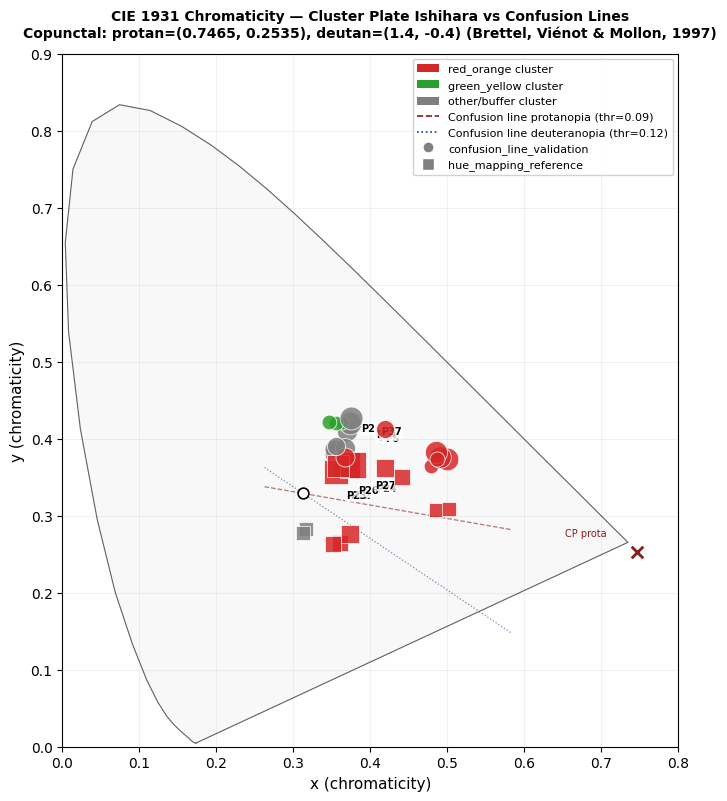

[3C] Overview disimpan: C:\Colorblind_correction\research\notebooks\03\output\chromaticity_overview.png


In [ ]:
# Tahap 3C: Chromaticity diagram overview

# Spektral locus CIE 1931 (380-700 nm, step 5 nm)
# Sumber: Colour & Vision Research Laboratory, UCL
_CIE_X = [
    0.1741,0.1740,0.1738,0.1736,0.1733,0.1730,0.1726,0.1721,0.1714,0.1703,
    0.1689,0.1669,0.1644,0.1611,0.1566,0.1510,0.1440,0.1355,0.1241,0.1096,
    0.0913,0.0687,0.0454,0.0235,0.0082,0.0039,0.0139,0.0389,0.0743,0.1142,
    0.1547,0.1929,0.2296,0.2658,0.3016,0.3373,0.3731,0.4087,0.4441,0.4788,
    0.5125,0.5448,0.5752,0.6029,0.6270,0.6482,0.6658,0.6801,0.6915,0.7006,
    0.7079,0.7140,0.7190,0.7230,0.7260,0.7283,0.7300,0.7311,0.7320,0.7327,
    0.7334,0.7340,0.7344,0.7346,
]
_CIE_Y = [
    0.0050,0.0050,0.0049,0.0049,0.0048,0.0048,0.0048,0.0048,0.0051,0.0058,
    0.0069,0.0086,0.0109,0.0138,0.0177,0.0227,0.0297,0.0399,0.0578,0.0868,
    0.1327,0.2007,0.2950,0.4127,0.5384,0.6548,0.7502,0.8120,0.8338,0.8262,
    0.8059,0.7816,0.7543,0.7243,0.6923,0.6589,0.6245,0.5896,0.5547,0.5202,
    0.4866,0.4544,0.4242,0.3965,0.3725,0.3514,0.3340,0.3197,0.3083,0.2993,
    0.2920,0.2859,0.2809,0.2770,0.2740,0.2717,0.2700,0.2689,0.2680,0.2673,
    0.2666,0.2660,0.2656,0.2654,
]

all_x  = [r["x"] for r in chroma_records]
x_lo   = max(0.0,  min(all_x) - 0.05)
x_hi   = min(0.76, max(all_x) + 0.08)

fig, ax = plt.subplots(figsize=(11, 9))

ax.plot(_CIE_X + [_CIE_X[0]], _CIE_Y + [_CIE_Y[0]], "k-", lw=0.8, alpha=0.6)
ax.fill(_CIE_X, _CIE_Y, alpha=0.05, color="gray")
ax.scatter(*WHITE_D65, s=60, c="white", edgecolors="black", lw=1.2,
           zorder=5, label="D65 (white point)")

# Confusion lines
for cvd_type, cp in COPUNCTAL.items():
    xs_cl, ys_cl = compute_confusion_line(cp, x_range=(x_lo, x_hi))
    thr = THRESH_MAP[cvd_type]
    ax.plot(xs_cl, ys_cl, **CVD_STYLE[cvd_type],
            label=f"Confusion line {cvd_type} (thr={thr})")
    ax.scatter(*cp, s=70, c=CVD_STYLE[cvd_type]["color"],
               marker="x", linewidths=2, zorder=6)
    ax.annotate(
        f"CP {cvd_type[:5]}",
        xy=cp, xytext=(cp[0] - 0.04, cp[1] + 0.02),
        fontsize=7, color=CVD_STYLE[cvd_type]["color"], ha="right",
    )

# Cluster points
plate_centers: dict[int, list] = {}
for rec in chroma_records:
    pn = rec["plate_number"]
    plate_centers.setdefault(pn, []).append((rec["x"], rec["y"]))
    ax.scatter(
        rec["x"], rec["y"],
        s=60 + rec["proportion"] * 380,
        c=CAT_COLOR.get(rec["hue_category"], "#7F7F7F"),
        marker=GROUP_MARKER.get(rec["group"], "D"),
        edgecolors="white", linewidths=0.6, alpha=0.85, zorder=7,
    )

for pn, pts in plate_centers.items():
    cx_m = float(np.mean([p[0] for p in pts]))
    cy_m = float(np.mean([p[1] for p in pts]))
    ax.annotate(
        f"P{pn}", xy=(cx_m, cy_m), xytext=(cx_m + 0.008, cy_m + 0.008),
        fontsize=7, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.75),
    )

legend_elems = [
    mpatches.Patch(facecolor="#D62728", label="red_orange cluster"),
    mpatches.Patch(facecolor="#2CA02C", label="green_yellow cluster"),
    mpatches.Patch(facecolor="#7F7F7F", label="other/buffer cluster"),
    Line2D([0],[0], color="#8B1A1A", ls="--", lw=1.2,
           label=f"Confusion line protanopia (thr={THRESHOLD_PROTAN})"),
    Line2D([0],[0], color="#1A3C8B", ls=":",  lw=1.2,
           label=f"Confusion line deuteranopia (thr={THRESHOLD_DEUTAN})"),
    Line2D([0],[0], marker="o", ls="none", ms=8, mfc="gray", mec="white",
           label="confusion_line_validation"),
    Line2D([0],[0], marker="s", ls="none", ms=8, mfc="gray", mec="white",
           label="hue_mapping_reference"),
]
ax.legend(handles=legend_elems, loc="upper right", fontsize=8, framealpha=0.9)
ax.set_xlim(0.0, 0.80)
ax.set_ylim(0.0, 0.90)
ax.set_xlabel("x (chromaticity)", fontsize=11)
ax.set_ylabel("y (chromaticity)", fontsize=11)
ax.set_title(
    "CIE 1931 Chromaticity — Cluster Plate Ishihara vs Confusion Lines\n"
    f"Copunctal: protan={COPUNCTAL['protanopia']}, "
    f"deutan={COPUNCTAL['deuteranopia']} ",
    fontsize=10, fontweight="bold", pad=12,
)
ax.grid(alpha=0.25, lw=0.5)
ax.set_aspect("equal")

out_overview = NB03_OUTPUT / "chromaticity_overview.png"
fig.savefig(str(out_overview), dpi=150, bbox_inches="tight")
plt.show()
print(f"[3C] Overview disimpan: {out_overview}")


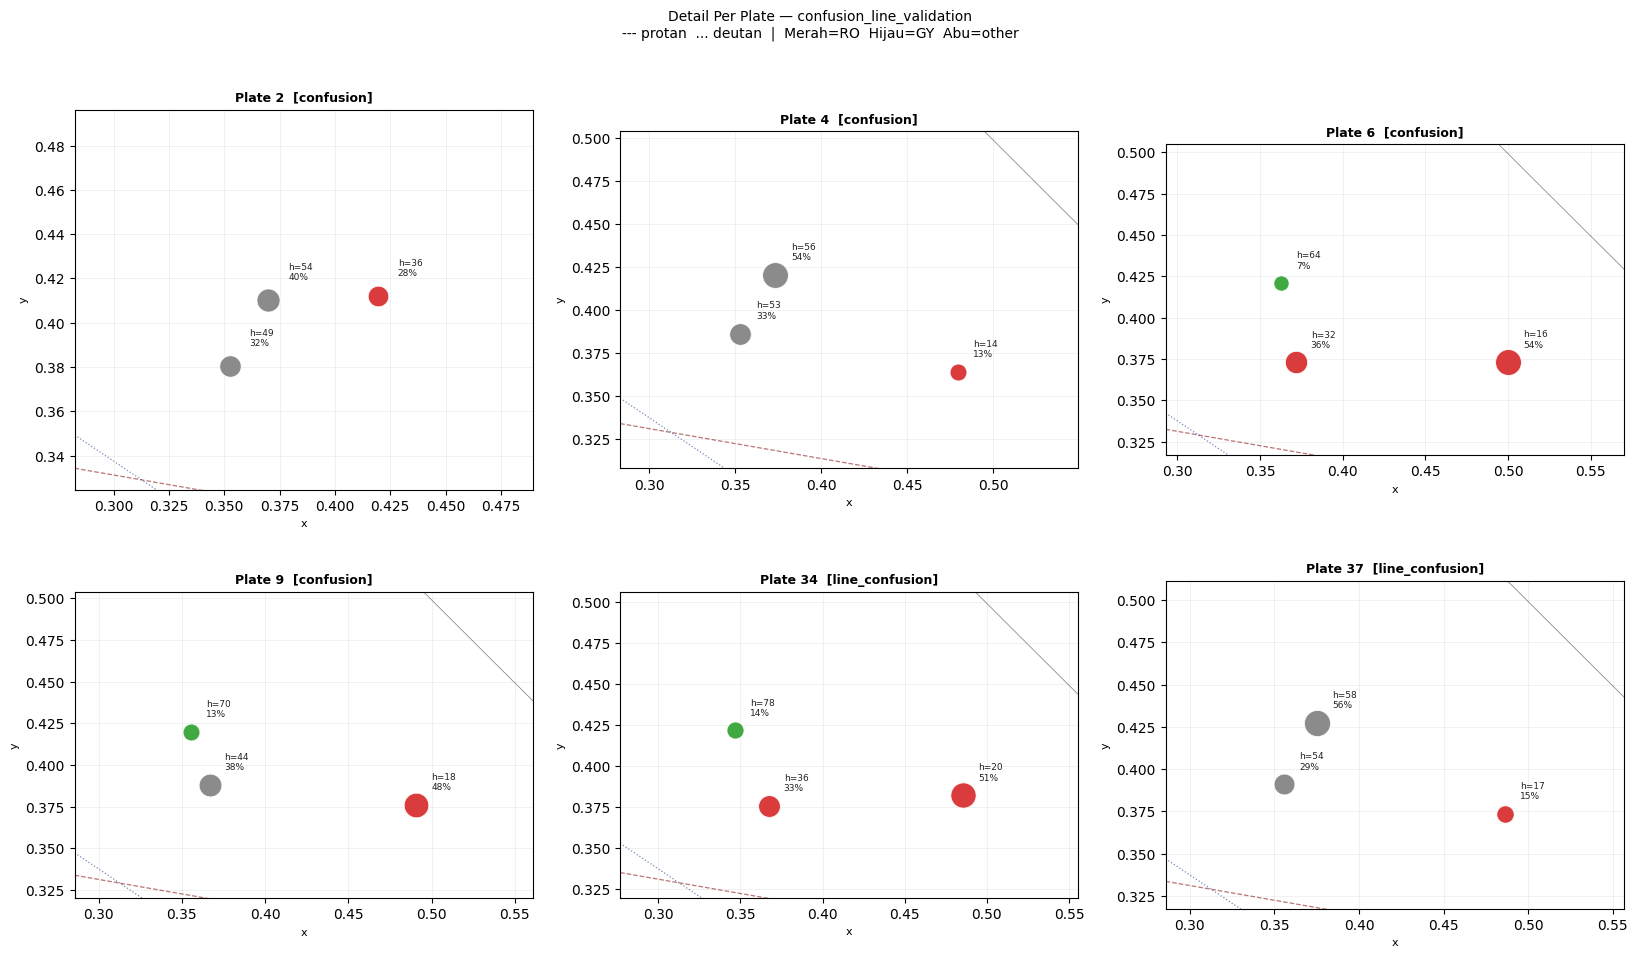

[3C] Per-plate disimpan: C:\Colorblind_correction\research\notebooks\03\output\chromaticity_per_plate.png


In [6]:
# Tahap 3C: Plot detail per plate (confusion_line_validation)
conf_plates = sorted({
    r["plate_number"] for r in chroma_records
    if r["group"] == "confusion_line_validation"
})
n_cols   = 3
n_rows   = -(-len(conf_plates) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5.5*n_cols, 4.8*n_rows))
axes_flat = axes.flatten() if n_rows > 1 else list(axes)

for idx, pn in enumerate(conf_plates):
    ax      = axes_flat[idx]
    recs    = chroma_by_plate.get(pn, [])
    xs_vals = [r["x"] for r in recs]
    ys_vals = [r["y"] for r in recs]
    pad     = 0.07

    ax.plot(_CIE_X + [_CIE_X[0]], _CIE_Y + [_CIE_Y[0]],
            "k-", lw=0.6, alpha=0.45)

    x_lo_p = max(0.0,  min(xs_vals) - pad)
    x_hi_p = min(0.78, max(xs_vals) + pad)
    for cvd_type, cp in COPUNCTAL.items():
        xs_cl, ys_cl = compute_confusion_line(cp, x_range=(x_lo_p, x_hi_p))
        ax.plot(xs_cl, ys_cl, **CVD_STYLE[cvd_type])

    for rec in recs:
        ax.scatter(
            rec["x"], rec["y"],
            s=85 + rec["proportion"] * 480,
            c=CAT_COLOR.get(rec["hue_category"], "#7F7F7F"),
            edgecolors="white", lw=0.6, alpha=0.9, zorder=5,
        )
        ax.annotate(
            f"h={rec['hue_360']:.0f}\n{rec['proportion']:.0%}",
            xy=(rec["x"], rec["y"]),
            xytext=(rec["x"] + 0.009, rec["y"] + 0.009),
            fontsize=6.5, color="#222",
        )

    ptype = plate_meta[pn]["answer_key"].get("type", "—")
    ax.set_title(f"Plate {pn}  [{ptype}]", fontsize=9, fontweight="bold")
    ax.set_xlim(x_lo_p, x_hi_p)
    ax.set_ylim(max(0, min(ys_vals) - pad*0.8), min(0.88, max(ys_vals) + pad*1.2))
    ax.set_xlabel("x", fontsize=8)
    ax.set_ylabel("y", fontsize=8)
    ax.grid(alpha=0.25, lw=0.5)
    ax.set_aspect("equal")

for j in range(len(conf_plates), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    "Detail Per Plate — confusion_line_validation\n"
    "--- protan  ... deutan  |  Merah=RO  Hijau=GY  Abu=other",
    fontsize=10, y=1.01,
)
plt.tight_layout()
out_per_plate = NB03_OUTPUT / "chromaticity_per_plate.png"
fig.savefig(str(out_per_plate), dpi=150, bbox_inches="tight")
plt.show()
print(f"[3C] Per-plate disimpan: {out_per_plate}")


In [7]:
# Sweep menunjukkan THRESHOLD_PROTAN/DEUTAN dipilih dari data, bukan arbitrary.
# Sweep pakai threshold tunggal per iterasi untuk eksplorasi visual — threshold
# final tetap dual (Cell 8).

def compute_all_distances(
    chroma_records: list[dict],
    copunctal     : dict[str, tuple[float, float]],
) -> dict[str, list[dict]]:
    """Hitung jarak tiap cluster RO/GY (grup confusion_line_validation) ke
    tiap confusion line. Cluster 'other' (buffer zone NB00) tidak dievaluasi.
    """
    relevant_cats = {"red_orange_candidate", "green_yellow_candidate"}
    result: dict[str, list[dict]] = {cvd: [] for cvd in copunctal}

    for rec in chroma_records:
        if rec["hue_category"] not in relevant_cats:
            continue
        if rec["group"] != "confusion_line_validation":
            continue
        for cvd_type, cp in copunctal.items():
            result[cvd_type].append({
                "plate"   : rec["plate_number"],
                "cat"     : rec["hue_category"],
                "hue"     : rec["hue_360"],
                "prop"    : rec["proportion"],
                "x"       : rec["x"],
                "y"       : rec["y"],
                "distance": distance_to_confline(rec["x"], rec["y"], cp),
            })
    return result


def _count_pass(validation_results: dict, cvd: str, threshold: float) -> int:
    """Hitung plate yang median jaraknya <= threshold untuk satu CVD type."""
    return sum(
        1 for res in validation_results.values()
        if res["status"] != "insufficient_data"
        and res["cvd_results"].get(cvd, {}).get("median_dist", 999) <= threshold
    )


all_dists = compute_all_distances(chroma_records, COPUNCTAL)

print("[3D] Distribusi jarak per CVD type:")
print()
for cvd_type, items in all_dists.items():
    if not items:
        print(f"  {cvd_type}: tidak ada data")
        continue
    dvals = [it["distance"] for it in items]
    print(f"  {cvd_type}:")
    print(f"    N        : {len(dvals)}")
    print(f"    Mean     : {np.mean(dvals):.4f}")
    print(f"    Median   : {np.median(dvals):.4f}")
    print(f"    Std      : {np.std(dvals):.4f}")
    print(f"    Min/Max  : {min(dvals):.4f} / {max(dvals):.4f}")
    print(f"    P25/P75  : {np.percentile(dvals,25):.4f} / "
          f"{np.percentile(dvals,75):.4f}")
    print()

# Per-plate median dulu untuk tabel sweep
plates_eval = sorted({it["plate"] for it in all_dists["protanopia"]})
plate_medians: dict[int, dict[str, float]] = {}
for pn in plates_eval:
    plate_medians[pn] = {}
    for cvd_type in COPUNCTAL:
        vals = [it["distance"] for it in all_dists[cvd_type]
                if it["plate"] == pn]
        plate_medians[pn][cvd_type] = float(np.median(vals)) if vals else 999.0

print("─" * 70)
print(f"  {'Threshold':>10}  {'Protan pass':>12}  {'Deutan pass':>12}  Note")
print(f"  {'─'*10}  {'─'*12}  {'─'*12}  {'─'*30}")
n_ev = len(plates_eval)
for thresh in THRESHOLD_CANDIDATES:
    n_p = sum(1 for pn in plates_eval
              if plate_medians[pn]["protanopia"]   <= thresh)
    n_d = sum(1 for pn in plates_eval
              if plate_medians[pn]["deuteranopia"] <= thresh)
    note = ""
    if thresh == THRESHOLD_PROTAN:
        note = "<-- THRESHOLD_PROTAN (pass semua protan)"
    if thresh == THRESHOLD_DEUTAN:
        note = "<-- THRESHOLD_DEUTAN (pass semua deutan)"
    print(f"  {thresh:>10.2f}  {n_p:>5}/{n_ev}        {n_d:>5}/{n_ev}        {note}")

print()
print("Kesimpulan sweep:")
print(f"  0.09 = titik minimum threshold agar SEMUA plate pass protanopia.")
print(f"  0.12 = titik minimum threshold agar SEMUA plate pass deuteranopia.")
print(f"  Konsisten dengan geometri: slope protan (~-0.15) vs deutan (~-0.04).")


[3D] Distribusi jarak per CVD type:

  protanopia:
    N        : 11
    Mean     : 0.0795
    Median   : 0.0768
    Std      : 0.0166
    Min/Max  : 0.0533 / 0.1002
    P25/P75  : 0.0684 / 0.0972

  deuteranopia:
    N        : 11
    Mean     : 0.1129
    Median   : 0.1220
    Std      : 0.0257
    Min/Max  : 0.0692 / 0.1408
    P25/P75  : 0.0978 / 0.1359

──────────────────────────────────────────────────────────────────────
   Threshold   Protan pass   Deutan pass  Note
  ──────────  ────────────  ────────────  ──────────────────────────────
        0.05      0/6            0/6        
        0.07      1/6            0/6        
        0.08      3/6            0/6        
        0.09      5/6            0/6        <-- THRESHOLD_PROTAN (pass semua protan)
        0.10      5/6            1/6        
        0.12      6/6            3/6        <-- THRESHOLD_DEUTAN (pass semua deutan)
        0.15      6/6            6/6        

Kesimpulan sweep:
  0.09 = titik minimum threshold a

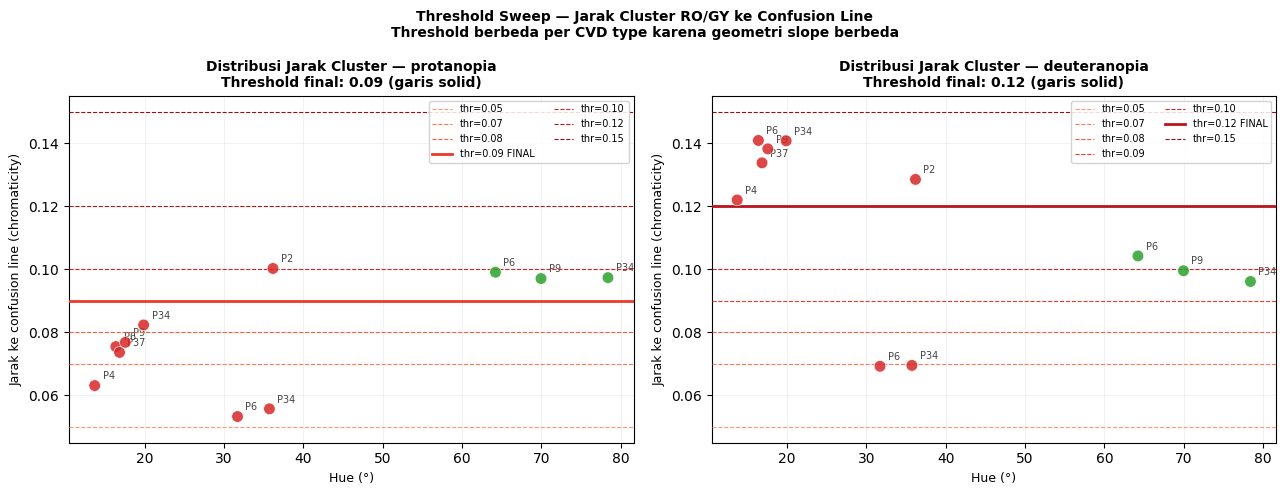

[3D] Sweep plot disimpan: C:\Colorblind_correction\research\notebooks\03\output\threshold_sweep.png

[3D] Validasi final — dual threshold:
     protanopia=0.09  deuteranopia=0.12

  Plate  Type                Status                Protan med    Deutan med   P   D
  ─────  ──────────────────  ──────────────────  ────────────  ────────────  ──  ──
      2  confusion           INSUFFICIENT                   —             —  —  —
      4  confusion           INSUFFICIENT                   —             —  —  —
      6  confusion           VALIDATED                 0.0755        0.1042  ok  ok
      9  confusion           VALIDATED                 0.0869        0.1188  ok  ok
     34  line_confusion      VALIDATED                 0.0823        0.0961  ok  ok
     37  line_confusion      INSUFFICIENT                   —             —  —  —

  Tervalidasi  : 3/6
  Insufficient : 3/6  (cluster dominan di buffer zone NB00)
  Not validated: 0/6



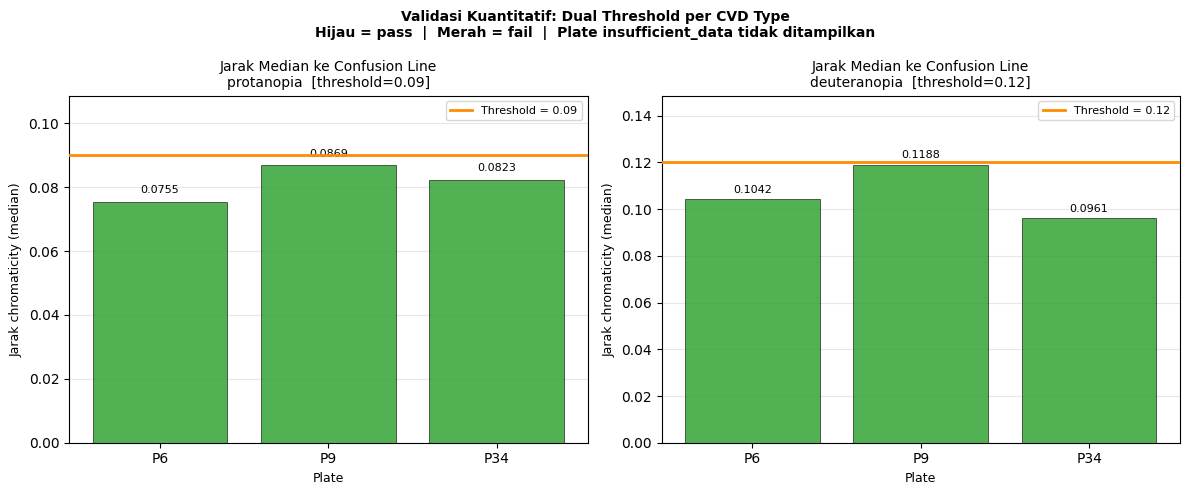

[3D] Bar chart disimpan: C:\Colorblind_correction\research\notebooks\03\output\validation_distances.png


In [8]:
# Tahap 3D: Plot sweep & validasi final dual threshold

# Plot scatter distribusi jarak
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax_idx, cvd_type in enumerate(COPUNCTAL):
    ax    = axes[ax_idx]
    items = all_dists[cvd_type]
    if not items:
        ax.set_visible(False)
        continue

    thr_final = THRESH_MAP[cvd_type]
    dvals  = [it["distance"] for it in items]
    hues   = [it["hue"]      for it in items]
    cats   = [it["cat"]      for it in items]
    plates = [it["plate"]    for it in items]

    ax.scatter(hues, dvals,
               c=[CAT_COLOR.get(c, "#7F7F7F") for c in cats],
               s=70, alpha=0.85, edgecolors="white", lw=0.5, zorder=5)

    for h, d, pn in zip(hues, dvals, plates):
        ax.annotate(f"P{pn}", xy=(h, d), xytext=(h+1, d+0.002),
                    fontsize=7, color="#444")

    colors_th = plt.cm.Reds(np.linspace(0.35, 0.90, len(THRESHOLD_CANDIDATES)))
    for thresh, col in zip(THRESHOLD_CANDIDATES, colors_th):
        is_final = (thresh == thr_final)
        ax.axhline(thresh, color=col,
                   ls="-" if is_final else "--",
                   lw=2.0 if is_final else 0.8,
                   label=f"thr={thresh:.2f}" + (" FINAL" if is_final else ""),
                   zorder=4 if is_final else 3)

    ax.set_xlabel("Hue (°)", fontsize=9)
    ax.set_ylabel("Jarak ke confusion line (chromaticity)", fontsize=9)
    ax.set_title(
        f"Distribusi Jarak Cluster — {cvd_type}\n"
        f"Threshold final: {thr_final} (garis solid)",
        fontsize=10, fontweight="bold",
    )
    ax.legend(fontsize=7, ncol=2, loc="upper right", framealpha=0.85)
    ax.grid(alpha=0.25, lw=0.5)

plt.suptitle(
    "Threshold Sweep — Jarak Cluster RO/GY ke Confusion Line\n"
    "Threshold berbeda per CVD type karena geometri slope berbeda",
    fontsize=10, fontweight="bold",
)
plt.tight_layout()
out_sweep = NB03_OUTPUT / "threshold_sweep.png"
fig.savefig(str(out_sweep), dpi=150, bbox_inches="tight")
plt.show()
print(f"[3D] Sweep plot disimpan: {out_sweep}")
print()

# Validasi final dual threshold
def validate_plate(
    plate_records   : list[dict],
    copunctal       : dict[str, tuple[float, float]],
    threshold_protan: float,
    threshold_deutan: float,
) -> dict:
    """Validasi satu plate via median jarak cluster RO+GY ke confusion line.

    Median dipakai agar robust terhadap outlier cluster kecil. Threshold beda
    per CVD type karena perbedaan geometri slope (lihat Cell 1/7). Plate
    dinyatakan valid jika median <= threshold untuk minimal satu CVD type.
    """
    relevant = [
        r for r in plate_records
        if r["hue_category"] in {"red_orange_candidate", "green_yellow_candidate"}
    ]

    if len(relevant) < 2:
        cats_found = {r["hue_category"] for r in plate_records}
        return {
            "status"     : "insufficient_data",
            "reason"     : (
                f"Hanya {len(relevant)} cluster dengan kategori jelas "
                f"(butuh >=2). Kategori tersedia: {cats_found}. "
                f"Cluster dominan kemungkinan masuk buffer zone NB00 "
                f"({hue_bounds['buffer_zone'][0]}--"
                f"{hue_bounds['buffer_zone'][1]} derajat)."
            ),
            "n_clusters" : len(relevant),
            "cvd_results": {},
        }

    thresh_map: dict[str, float] = {
        "protanopia"  : threshold_protan,
        "deuteranopia": threshold_deutan,
    }

    cvd_results: dict = {}
    for cvd_type, cp in copunctal.items():
        dists    = [distance_to_confline(r["x"], r["y"], cp) for r in relevant]
        median_d = float(np.median(dists))
        thr      = thresh_map[cvd_type]
        cvd_results[cvd_type] = {
            "copunctal"  : list(cp),
            "distances"  : [round(d, 6) for d in dists],
            "mean_dist"  : round(float(np.mean(dists)), 5),
            "median_dist": round(median_d,              5),
            "max_dist"   : round(float(np.max(dists)),  5),
            "threshold"  : thr,
            "passed"     : median_d <= thr,
        }

    any_pass = any(v["passed"] for v in cvd_results.values())
    return {
        "status"     : "validated" if any_pass else "not_validated",
        "n_clusters" : len(relevant),
        "cvd_results": cvd_results,
    }


conf_plate_nums = sorted({
    r["plate_number"] for r in chroma_records
    if r["group"] == "confusion_line_validation"
})
validation_results: dict[int, dict] = {}

print(f"[3D] Validasi final — dual threshold:")
print(f"     protanopia={THRESHOLD_PROTAN}  deuteranopia={THRESHOLD_DEUTAN}")
print()
print(f"  {'Plate':>5}  {'Type':<18}  {'Status':<18}"
      f"  {'Protan med':>12}  {'Deutan med':>12}  {'P':>2}  {'D':>2}")
print(f"  {'─'*5}  {'─'*18}  {'─'*18}"
      f"  {'─'*12}  {'─'*12}  {'─'*2}  {'─'*2}")

for pn in conf_plate_nums:
    recs   = chroma_by_plate.get(pn, [])
    result = validate_plate(recs, COPUNCTAL, THRESHOLD_PROTAN, THRESHOLD_DEUTAN)
    validation_results[pn] = result
    ptype  = plate_meta[pn]["answer_key"].get("type", "—")

    if result["status"] == "insufficient_data":
        print(f"  {pn:>5}  {ptype:<18}  {'INSUFFICIENT':<18}"
              f"  {'—':>12}  {'—':>12}  —  —")
        continue

    cvd   = result["cvd_results"]
    p_med = cvd["protanopia"]["median_dist"]
    d_med = cvd["deuteranopia"]["median_dist"]
    p_ok  = "ok" if cvd["protanopia"]["passed"]   else "x"
    d_ok  = "ok" if cvd["deuteranopia"]["passed"] else "x"
    print(f"  {pn:>5}  {ptype:<18}  {result['status'].upper():<18}"
          f"  {p_med:>12.4f}  {d_med:>12.4f}  {p_ok}  {d_ok}")

n_val = sum(1 for r in validation_results.values() if r["status"] == "validated")
n_ins = sum(1 for r in validation_results.values() if r["status"] == "insufficient_data")
n_tot = len(validation_results)
print()
print(f"  Tervalidasi  : {n_val}/{n_tot}")
print(f"  Insufficient : {n_ins}/{n_tot}  (cluster dominan di buffer zone NB00)")
print(f"  Not validated: {n_tot-n_val-n_ins}/{n_tot}")
print()

# Bar chart jarak median
plates_w_data = [pn for pn, res in validation_results.items()
                 if res["status"] != "insufficient_data"]

if plates_w_data:
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    for ax_idx, cvd_type in enumerate(COPUNCTAL):
        ax      = axes2[ax_idx]
        thr     = THRESH_MAP[cvd_type]
        labels  = [f"P{pn}" for pn in plates_w_data]
        medians = [validation_results[pn]["cvd_results"][cvd_type]["median_dist"]
                   for pn in plates_w_data]
        colors  = ["#2CA02C"
                   if validation_results[pn]["cvd_results"][cvd_type]["passed"]
                   else "#D62728"
                   for pn in plates_w_data]

        bars = ax.bar(labels, medians, color=colors, alpha=0.82,
                      edgecolor="black", lw=0.5, zorder=4)
        ax.axhline(thr, color="darkorange", lw=2.0, ls="-",
                   label=f"Threshold = {thr}", zorder=5)

        for bar, val in zip(bars, medians):
            ax.text(bar.get_x() + bar.get_width()/2, val + 0.002,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=8)

        ax.set_title(
            f"Jarak Median ke Confusion Line\n"
            f"{cvd_type}  [threshold={thr}]",
            fontsize=10,
        )
        ax.set_xlabel("Plate", fontsize=9)
        ax.set_ylabel("Jarak chromaticity (median)", fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=0.3, zorder=1)
        ax.set_ylim(0, max(medians) * 1.25)

    plt.suptitle(
        "Validasi Kuantitatif: Dual Threshold per CVD Type\n"
        "Hijau = pass  |  Merah = fail  |"
        "  Plate insufficient_data tidak ditampilkan",
        fontsize=10, fontweight="bold",
    )
    plt.tight_layout()
    out_bar = NB03_OUTPUT / "validation_distances.png"
    fig2.savefig(str(out_bar), dpi=150, bbox_inches="tight")
    plt.show()
    print(f"[3D] Bar chart disimpan: {out_bar}")


In [9]:
# 3 plate (2, 4, 37) tidak bisa divalidasi formal karena cluster dominannya
# (hue 49-58 derajat) masuk buffer zone NB00. Proximity analysis menghitung
# jarak SEMUA cluster (termasuk 'other') sebagai observasi tambahan —
# tidak mengubah boundary NB00 atau hasil validasi formal.

def proximity_analysis(
    plate_number  : int,
    chroma_records: list[dict],
    copunctal     : dict[str, tuple[float, float]],
) -> dict:
    """Hitung jarak semua cluster (termasuk 'other') ke confusion line — purely observational."""
    recs   = chroma_by_plate.get(plate_number, [])
    result : dict = {"plate_number": plate_number, "cvd_proximity": {}}

    for cvd_type, cp in copunctal.items():
        thr = THRESHOLD_PROTAN if cvd_type == "protanopia" else THRESHOLD_DEUTAN
        cluster_dists = sorted(
            [{"hue"     : rec["hue_360"],
              "cat"     : rec["hue_category"],
              "prop"    : rec["proportion"],
              "distance": round(distance_to_confline(rec["x"], rec["y"], cp), 6)}
             for rec in recs],
            key=lambda x: x["distance"],
        )
        dvals = [c["distance"] for c in cluster_dists]
        result["cvd_proximity"][cvd_type] = {
            "threshold" : thr,
            "clusters"  : cluster_dists,
            "median_all": round(float(np.median(dvals)), 5) if dvals else None,
            "min_dist"  : round(float(np.min(dvals)),    5) if dvals else None,
        }
    return result


insuff_plates = sorted(
    pn for pn, res in validation_results.items()
    if res["status"] == "insufficient_data"
)
proximity_results: dict[int, dict] = {}

buf_lo = hue_bounds["buffer_zone"][0]
buf_hi = hue_bounds["buffer_zone"][1]
print(f"[3E] Proximity Analysis — plate insufficient_data")
print(f"     (buffer zone NB00: {buf_lo} -- {buf_hi} derajat)")
print()

for pn in insuff_plates:
    res = proximity_analysis(pn, chroma_records, COPUNCTAL)
    proximity_results[pn] = res
    print(f"  Plate {pn}:")
    for cvd_type, pdata in res["cvd_proximity"].items():
        print(f"    [{cvd_type}] thr={pdata['threshold']}  "
              f"median_all={pdata['median_all']:.4f}  "
              f"min={pdata['min_dist']:.4f}")
        for cl in pdata["clusters"]:
            mark = "*" if cl["distance"] <= pdata["threshold"] else " "
            print(f"      {mark} h={cl['hue']:>6.1f}  "
                  f"cat={cl['cat']:<28}  "
                  f"prop={cl['prop']:.0%}  "
                  f"dist={cl['distance']:.4f}")
    print()

print("'*' = cluster yang jaraknya <= threshold jika dievaluasi formal.")
print("Cluster 'other' masuk buffer zone karena hue 49-58 derajat berada")
print("di antara RO_MAX dan GY_MIN NB00 -- sengaja diexclude untuk")
print("menghindari ambiguitas yellow-orange pada K-Means NB02.")


[3E] Proximity Analysis — plate insufficient_data
     (buffer zone NB00: 35 -- 65 derajat)

  Plate 2:
    [protanopia] thr=0.09  median_all=0.0900  min=0.0576
      * h=  49.5  cat=other                         prop=32%  dist=0.0577
        h=  53.8  cat=other                         prop=40%  dist=0.0900
        h=  36.2  cat=red_orange_candidate          prop=28%  dist=0.1002
    [deuteranopia] thr=0.12  median_all=0.0995  min=0.0650
      * h=  49.5  cat=other                         prop=32%  dist=0.0650
      * h=  53.8  cat=other                         prop=40%  dist=0.0995
        h=  36.2  cat=red_orange_candidate          prop=28%  dist=0.1285

  Plate 4:
    [protanopia] thr=0.09  median_all=0.0635  min=0.0631
      * h=  13.7  cat=red_orange_candidate          prop=13%  dist=0.0631
      * h=  53.4  cat=other                         prop=33%  dist=0.0635
        h=  56.2  cat=other                         prop=54%  dist=0.1005
    [deuteranopia] thr=0.12  median_all=0.109

In [ ]:
def _build_sweep_summary(
    validation_results  : dict,
    copunctal           : dict,
    threshold_candidates: list[float],
) -> dict:
    """Bangun tabel pass count per threshold per CVD type (dipisah dari
    comprehension bersarang agar tidak pakai walrus operator rawan bug scope).
    """
    summary: dict = {}
    for thresh in threshold_candidates:
        summary[str(thresh)] = {}
        for cvd in copunctal:
            summary[str(thresh)][cvd] = _count_pass(validation_results, cvd, thresh)
    return summary


# n_val, n_ins, n_tot sudah dihitung di Cell 8 — hanya perlu n_ev
n_ev = n_tot - n_ins

# Range jarak aktual dihitung dari data agar interpretasi tidak stale
# jika cluster NB00 berubah di kemudian hari.
_eval_results = [
    res for res in validation_results.values()
    if res["status"] != "insufficient_data"
]
_protan_meds = [r["cvd_results"]["protanopia"]["median_dist"]   for r in _eval_results]
_deutan_meds = [r["cvd_results"]["deuteranopia"]["median_dist"] for r in _eval_results]
_p_range = f"{min(_protan_meds):.3f}-{max(_protan_meds):.3f}" if _protan_meds else "—"
_d_range = f"{min(_deutan_meds):.3f}-{max(_deutan_meds):.3f}" if _deutan_meds else "—"
_p_pass  = sum(1 for r in _eval_results if r["cvd_results"]["protanopia"]["passed"])
_d_pass  = sum(1 for r in _eval_results if r["cvd_results"]["deuteranopia"]["passed"])

payload: dict = {
    "timestamp"        : datetime.datetime.now().isoformat(),
    "notebook_version" : "v3-dual-threshold",
    "method": (
        "Validasi chromaticity CIE 1931: jarak tegak lurus cluster HSV "
        "ke confusion line dari copunctal point masing-masing CVD type "
        "Threshold ditetapkan terpisah per CVD type karena perbedaan "
        "geometri slope confusion line. "
        "Threshold ditentukan melalui sweep empiris pada THRESHOLD_CANDIDATES "
        "dan dipilih sebagai nilai minimum agar semua plate pass per CVD type. "
        "Agregasi menggunakan median (robust terhadap outlier cluster)."
    ),
    "references": {
        "copunctal_points": (
            "Computerized simulation of color appearance for dichromats. "
            "JOSA A 14(10), 2647-2655. Tabel 1."
        ),
        "threshold_basis": (
            "Dual threshold justified oleh geometri: "
            f"protanopia copunctal {COPUNCTAL['protanopia']} menghasilkan slope ~-0.15 "
            f"(threshold {THRESHOLD_PROTAN}); "
            f"deuteranopia copunctal {COPUNCTAL['deuteranopia']} menghasilkan "
            f"slope ~-0.04 (threshold {THRESHOLD_DEUTAN}). "
            "Offset dari confusion line ideal disebabkan: "
            "(1) PDF/CMYK ke sRGB shift 0.02-0.04; "
            "(2) deliberate Ishihara offset (Cole & Lian, 2006) 0.02-0.05; "
            "(3) K-Means centroid dispersion 0.01-0.03. Total: 0.05-0.12."
        ),
        "min_prop_filter": (
            "Wyszecki & Stiles, Color Science (2000): "
            "konvensi noise filter 5% dalam color quantization."
        ),
    },
    "parameters": {
        "copunctal_points"      : COPUNCTAL,
        "white_point_d65"       : WHITE_D65,
        "threshold_protan"      : THRESHOLD_PROTAN,
        "threshold_deutan"      : THRESHOLD_DEUTAN,
        "threshold_candidates"  : THRESHOLD_CANDIDATES,
        "min_prop_filter"       : MIN_PROP_FILTER,
        "groups_validated"      : sorted(GROUPS_FOR_VALIDATION),
    },
    "hue_boundaries_source": {
        "file"             : str(NB00_OUTPUT / "derived_hue_boundaries.json"),
        "red_orange_max"   : hue_bounds["red_orange_max"],
        "red_orange_min"   : hue_bounds["red_orange_min"],
        "green_yellow_min" : hue_bounds["green_yellow_min"],
        "green_yellow_max" : hue_bounds["green_yellow_max"],
        "buffer_zone"      : hue_bounds["buffer_zone"],
    },
    "per_plate_results" : {},
    "proximity_analysis": {},
    "summary"           : {},
}

for pn, res in sorted(validation_results.items()):
    meta = plate_meta[pn]
    recs = chroma_by_plate.get(pn, [])
    payload["per_plate_results"][str(pn)] = {
        "plate_number": pn,
        "group"       : meta["group"],
        "plate_type"  : meta["answer_key"].get("type"),
        "answer_key"  : meta["answer_key"],
        "n_clusters"  : res.get("n_clusters", 0),
        "status"      : res["status"],
        "reason"      : res.get("reason"),
        "cvd_results" : res.get("cvd_results", {}),
        "chromaticity_clusters": [
            {k: r[k] for k in
             ("x", "y", "hue_360", "proportion", "hue_category")}
            for r in recs
        ],
    }

for pn, pres in sorted(proximity_results.items()):
    payload["proximity_analysis"][str(pn)] = pres

payload["summary"] = {
    "total_plates_evaluated"   : n_tot,
    "validated"                : n_val,
    "insufficient_data"        : n_ins,
    "not_validated"            : n_tot - n_val - n_ins,
    "validation_rate_evaluable": round(n_val / max(1, n_ev) * 100, 1),
    "threshold_sweep_summary"  : _build_sweep_summary(
        validation_results, COPUNCTAL, THRESHOLD_CANDIDATES
    ),
    "interpretation": (
        f"Dari {n_ev} plate yang dapat dievaluasi penuh, {n_val} plate "
        f"tervalidasi (rate: {round(n_val / max(1, n_ev) * 100, 1)}%). "
        f"Jarak median protan: {_p_range} "
        f"(threshold {THRESHOLD_PROTAN}, {_p_pass}/{n_ev} pass). "
        f"Jarak median deutan: {_d_range} "
        f"(threshold {THRESHOLD_DEUTAN}, {_d_pass}/{n_ev} pass). "
        f"{n_ins} plate tidak terevaluasi karena cluster dominan di "
        f"buffer zone NB00 ({hue_bounds['buffer_zone'][0]}-"
        f"{hue_bounds['buffer_zone'][1]} derajat)."
    ),
    "note_insufficient": (
        f"{n_ins} plate tidak dapat dievaluasi formal karena cluster "
        f"dominan (hue 49-58 derajat) masuk buffer zone NB00 "
        f"({hue_bounds['buffer_zone'][0]}-{hue_bounds['buffer_zone'][1]} "
        f"derajat). Ini limitasi metodologis yang terdokumentasi, bukan bug. "
        "Lihat proximity_analysis untuk analisis geometris tambahan."
    ),
}

out_json = NB03_OUTPUT / "confusion_line_validation.json"
with open(out_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2, ensure_ascii=False)

print(f"[3F] Ekspor selesai: {out_json}")
print()

s = payload["summary"]
print("=" * 65)
print("  RINGKASAN NB03 — CONFUSION LINE VALIDATION")
print("=" * 65)
print()
print(f"  Plate dievaluasi   : {s['total_plates_evaluated']}")
print(f"  Tervalidasi        : {s['validated']}  "
      f"(dari {n_ev} yang terevaluasi, rate {s['validation_rate_evaluable']}%)")
print(f"  Insufficient data  : {s['insufficient_data']}  "
      f"(cluster dominan di buffer zone NB00)")
print(f"  Not validated      : {s['not_validated']}")
print()
print(f"  Threshold: protan={THRESHOLD_PROTAN}, deutan={THRESHOLD_DEUTAN}")
print(f"  (Dual threshold justified oleh perbedaan geometri slope confusion line)")
print()
print(f"  {'Plate':>5}  {'Type':<16}  {'Protan med':>12}  {'Deutan med':>12}  Status")
print(f"  {'─'*5}  {'─'*16}  {'─'*12}  {'─'*12}  {'─'*14}")
for pn, res in sorted(validation_results.items()):
    ptype = plate_meta[pn]["answer_key"].get("type", "-")
    if res["status"] == "insufficient_data":
        print(f"  {pn:>5}  {ptype:<16}  {'—':>12}  {'—':>12}  INSUFFICIENT DATA")
        continue
    cvd   = res["cvd_results"]
    p_med = cvd["protanopia"]["median_dist"]
    d_med = cvd["deuteranopia"]["median_dist"]
    p_ok  = "ok" if cvd["protanopia"]["passed"]   else "x"
    d_ok  = "ok" if cvd["deuteranopia"]["passed"] else "x"
    print(f"  {pn:>5}  {ptype:<16}  "
          f"{p_ok} {p_med:>9.4f}  {d_ok} {d_med:>9.4f}  {res['status'].upper()}")

print()
print(f"  Threshold sweep (plate pass dari {n_ev} yang terevaluasi):")
print(f"  {'Threshold':>10}  {'Protanopia':>12}  {'Deuteranopia':>14}")
for t_str, cvd_counts in s["threshold_sweep_summary"].items():
    marks = ""
    t = float(t_str)
    if t == THRESHOLD_PROTAN:
        marks += f" <- THRESHOLD_PROTAN"
    if t == THRESHOLD_DEUTAN:
        marks += f" <- THRESHOLD_DEUTAN"
    print(f"  {t:>10.2f}  "
          f"{cvd_counts.get('protanopia', 0):>4}/{n_ev}          "
          f"{cvd_counts.get('deuteranopia', 0):>4}/{n_ev}       {marks}")

print()
print(f"  Interpretasi:")
print(f"  {s['interpretation']}")
print()
print("  Output NB03 v3:")
for fname in [
    "chromaticity_overview.png   -- CIE 1931 overview semua cluster",
    "chromaticity_per_plate.png  -- detail per plate",
    "threshold_sweep.png         -- distribusi jarak + semua kandidat threshold",
    "validation_distances.png    -- bar chart final dual threshold",
    "confusion_line_validation.json -- data ekspor lengkap (dibaca NB04)",
]:
    print(f"    {fname}")
print(f"  Semua di: {NB03_OUTPUT}")
print()


[3F] Ekspor selesai: C:\Colorblind_correction\research\notebooks\03\output\confusion_line_validation.json

  RINGKASAN NB03 — CONFUSION LINE VALIDATION

  Plate dievaluasi   : 6
  Tervalidasi        : 3  (dari 3 yang terevaluasi, rate 100.0%)
  Insufficient data  : 3  (cluster dominan di buffer zone NB00)
  Not validated      : 0

  Threshold: protan=0.09, deutan=0.12
  (Dual threshold justified oleh perbedaan geometri slope confusion line)

  Plate  Type                Protan med    Deutan med  Status
  ─────  ────────────────  ────────────  ────────────  ──────────────
      2  confusion                    —             —  INSUFFICIENT DATA
      4  confusion                    —             —  INSUFFICIENT DATA
      6  confusion         ok    0.0755  ok    0.1042  VALIDATED
      9  confusion         ok    0.0869  ok    0.1188  VALIDATED
     34  line_confusion    ok    0.0823  ok    0.0961  VALIDATED
     37  line_confusion               —             —  INSUFFICIENT DATA

  Thres

## Catatan Metodologis untuk Skripsi

Threshold dual (protan 0.09, deutan 0.12) diturunkan dari geometri slope
confusion line tiap CVD type, bukan dipilih agar semua pass — lihat Cell 1
untuk detail geometri dan Cell 7 untuk konfirmasi sweep empiris.

**Limitasi yang terdokumentasi:**
1. 3 dari 6 plate berstatus `insufficient_data` — cluster dominan (hue 49–58°)
   masuk buffer zone NB00. Lihat `proximity_analysis` di JSON ekspor untuk
   analisis geometris tambahan yang menunjukkan cluster tersebut sebenarnya
   dekat confusion line secara observasional.
2. Offset dari confusion line ideal berasal dari toleransi desain Ishihara
   dan distorsi gamut PDF/CMYK→sRGB.

**Output yang dibaca NB04:** `confusion_line_validation.json` →
`parameters.copunctal_points` dan `parameters.white_point_d65` dipakai
NB04 sebagai sumber tunggal titik copunctal (menghindari duplikasi
konstanta antar notebook), serta `summary.validated` sebagai gate
precondition sebelum generasi soal dijalankan. NB04 tidak menggunakan
`per_plate_results` — copunctal yang dipakai bersifat global per CVD
type, bukan dikalibrasi per plate.